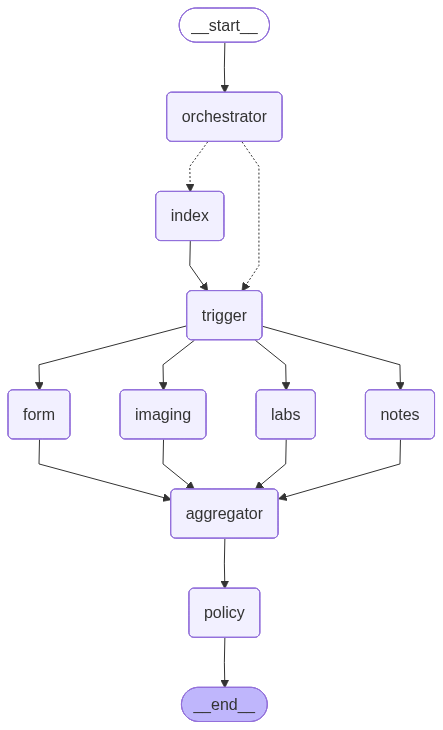

In [6]:
from langgraph.graph import StateGraph, END

from nodes.Form_node import form_node
from nodes.Labs_node import labs_node
from nodes.Imaging_node import imaging_node
from nodes.Notes_node import notes_node
from nodes.Orchestrator_node import orchestrator_node
from nodes.Aggregator_node import aggregator_node
from nodes.Policy_node import policy_node
from nodes.index_node import index_node

from State import PriorAuthState


def route_from_orchestrator(state):
    if state.get("index_ready"):
        return "trigger"   # go to fan-out
    return "index"


def build_graph():

    workflow = StateGraph(PriorAuthState)

    # ----------------------------
    # Nodes
    # ----------------------------
    workflow.add_node("orchestrator", orchestrator_node)
    workflow.add_node("index", index_node)

    # 🔥 NEW: trigger node for fan-out
    workflow.add_node("trigger", lambda state: {})

    workflow.add_node("form", form_node)
    workflow.add_node("labs", labs_node)
    workflow.add_node("imaging", imaging_node)
    workflow.add_node("notes", notes_node)

    workflow.add_node("aggregator", aggregator_node)
    workflow.add_node("policy", policy_node)

    # ----------------------------
    # Entry
    # ----------------------------
    workflow.set_entry_point("orchestrator")

    # ----------------------------
    # Conditional routing
    # ----------------------------
    workflow.add_conditional_edges(
        "orchestrator",
        route_from_orchestrator,
        ["index", "trigger"]
    )

    # ----------------------------
    # After index → go to trigger
    # ----------------------------
    workflow.add_edge("index", "trigger")

    # ----------------------------
    # FAN-OUT (clean)
    # ----------------------------
    workflow.add_edge("trigger", "form")
    workflow.add_edge("trigger", "labs")
    workflow.add_edge("trigger", "imaging")
    workflow.add_edge("trigger", "notes")

    # ----------------------------
    # FAN-IN
    # ----------------------------
    workflow.add_edge("form", "aggregator")
    workflow.add_edge("labs", "aggregator")
    workflow.add_edge("imaging", "aggregator")
    workflow.add_edge("notes", "aggregator")

    # ----------------------------
    # Final
    # ----------------------------
    workflow.add_edge("aggregator", "policy")
    workflow.add_edge("policy", END)

    return workflow.compile()


graph = build_graph()

display(Image(graph.get_graph().draw_mermaid_png()))